In [63]:
###################### Part 3: NLP and Sequence Modeling Mini Project ###########################

# Imports

from pathlib import Path
import random

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [64]:
# Create Output Directory

Path("results").mkdir(exist_ok=True)

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# Dataset Path
DATA_PATH = Path("/content/drive/MyDrive/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

In [67]:
# Load Dataset

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dataset not found at: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)

print('Dataset Loaded Successfully')
print(df.head())

Dataset Loaded Successfully
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


Dataset Shape: (1500, 6)

Columns:
['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample 1
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Sample 2
I need information about the payment process.

Sample 3
The refund process was fast and convenient. I appreciate the quick response.

Sample 4
My refund is still pending and this experience is frustrating. My ticket number is 33927.

Sample 5
Please tell me how to update my account details.

Average Text Length: 12.722666666666667


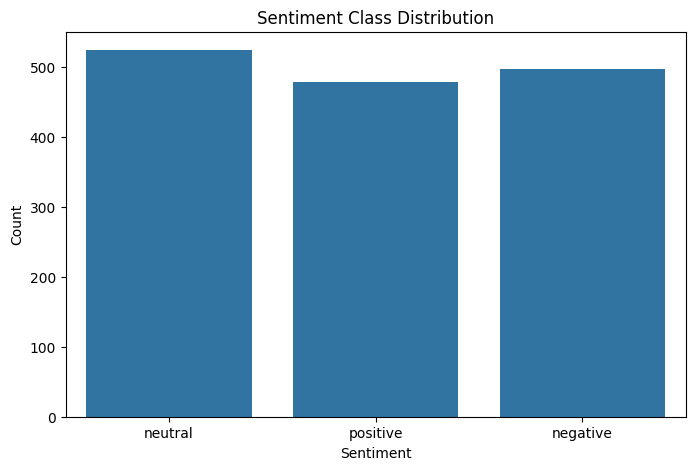

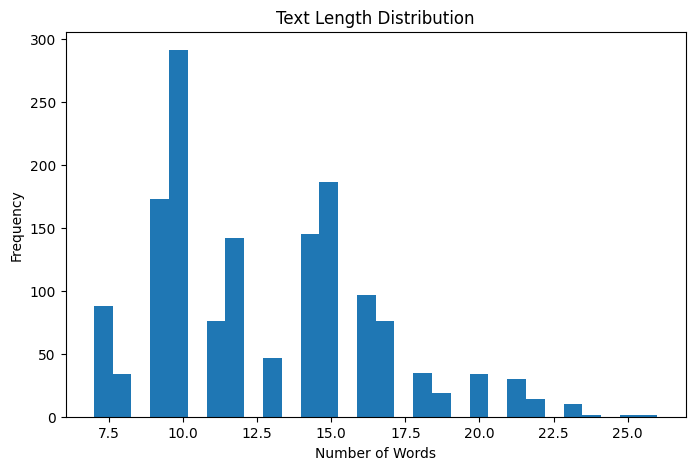

In [68]:
########################################## Task 1: Dataset Understanding ###################################


# Define Dataset Columns
TEXT_COLUMN = 'customer_message'
LABEL_COLUMN = 'sentiment_label'

# Dataset Shape
print('Dataset Shape:', df.shape)

# Column Information

print('\nColumns:')
print(df.columns.tolist())

# Class Distribution
print('\nClass Distribution:')
print(df[LABEL_COLUMN].value_counts())

# Sample Text Records
for i in range(5):
    print(f'\nSample {i+1}')
    print(df[TEXT_COLUMN].iloc[i])

# Average Text Length
df['calculated_text_length'] = df[TEXT_COLUMN].apply(
    lambda x: len(str(x).split())
)

print(
    '\nAverage Text Length:',
    df['calculated_text_length'].mean()
)

# Class Distribution Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    x=LABEL_COLUMN,
    data=df
)

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.savefig('results/class_distribution.png')

plt.show()

# Text Length Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df['calculated_text_length'],
    bins=30
)

plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

In [69]:
########################## Task 2: Text Preprocessing ############################

stop_words = set(stopwords.words('english'))

# Clean the text data

def clean_text(text):

    # Lowercasing
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\\S+', '', text)

    # Remove unnecessary symbols or special characters
    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return ' '.join(tokens)

# Apply Cleaning
df['clean_text'] = df[TEXT_COLUMN].apply(clean_text)

print(
    df[[TEXT_COLUMN, 'clean_text']].head()
)

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  ineedinformationaboutthepaymentprocessmyticket...  
1             ineedinformationaboutthepaymentprocess  
2  therefundprocesswasfastandconvenientiappreciat...  
3  myrefundisstillpendingandthisexperienceisfrust...  
4            pleasetellmehowtoupdatemyaccountdetails  


In [70]:
# Train-Test Split
X = df['clean_text']
y = df[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
####################################### Task 3: Text Vectorization ########################

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(1200, 245)


## Why text must be converted into vectors before being used by a model

Text must be converted into vectors because machine learning models operate only on numerical data representations.

In [72]:
###################################### Task 4: Baseline Model #########################

# Logistic Regression with TF-IDF
baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

y_pred = baseline_model.predict(
    X_test_tfidf
)

Accuracy: 0.9733333333333334

Classification Report:

              precision    recall  f1-score   support

    negative       0.93      1.00      0.96        99
     neutral       1.00      0.97      0.99       105
    positive       1.00      0.95      0.97        96

    accuracy                           0.97       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.97      0.97       300



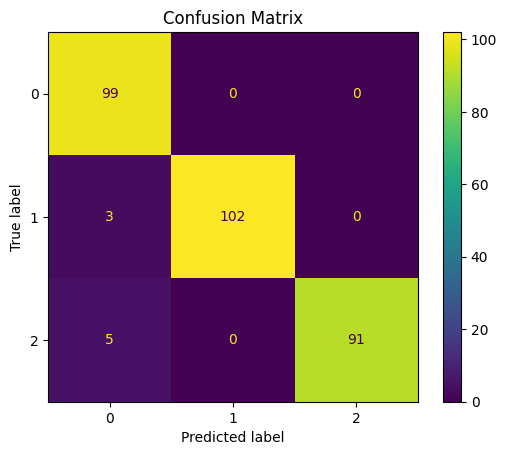

In [73]:
# Evaluate the model using appropriate metrics

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print('Accuracy:', accuracy)

# Classification Report
print('\nClassification Report:\n')

print(
    classification_report(
        y_test,
        y_pred
    )
)

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title('Confusion Matrix')

plt.savefig(
    'results/confusion_matrix.png'
)

plt.show()

In [74]:
##################### Task 5: Sequence Model or Conceptual Architecture #############################

# Sequence Modeling — LSTM

# Tokenization
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

# Padding Sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)



In [75]:
# Encode Labels

# This is REQUIRED because labels are text.
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [76]:
# Build LSTM Model

#Since the dataset is multiclass:  positive, neutral, negative, so we use softmax output.

num_classes = len(label_encoder.classes_)

model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

In [77]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Train Model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.3448 - loss: 1.1019 - val_accuracy: 0.3042 - val_loss: 1.1019
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3135 - loss: 1.0995 - val_accuracy: 0.3375 - val_loss: 1.1039
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.3510 - loss: 1.1000 - val_accuracy: 0.3375 - val_loss: 1.1004
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.3323 - loss: 1.0994 - val_accuracy: 0.3375 - val_loss: 1.1018
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.3583 - loss: 1.0975 - val_accuracy: 0.3375 - val_loss: 1.1029
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - accuracy: 0.3365 - loss: 1.0983 - val_accuracy: 0.3375 - val_loss: 1.1013


In [79]:
# Evaluate LSTM Model

loss, accuracy = model.evaluate(
    X_test_pad,
    y_test_encoded
)

print('Test Accuracy:', accuracy)

# LSTM Predictions

pred_probs = model.predict(X_test_pad)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

pred_labels = label_encoder.inverse_transform(
    pred_classes
)

print(pred_labels[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3500 - loss: 1.0980
Test Accuracy: 0.3499999940395355
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
['neutral' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral'
 'neutral' 'neutral' 'neutral']


# TASK 5: Sequence Modeling Architecture — LSTM

## Overview

A Long Short-Term Memory (LSTM) based sequence model was implemented for sentiment classification of customer support messages.

The objective of the model is to classify customer messages into one of the following sentiment categories:

- Positive
- Neutral
- Negative

Unlike traditional machine learning approaches such as TF-IDF with Logistic Regression, the LSTM model processes text sequentially and preserves contextual relationships between words.

---

### Model Architecture

```text
Customer Message
        ↓
Text Cleaning
        ↓
Tokenization
        ↓
Sequence Padding
        ↓
Embedding Layer
        ↓
LSTM Layer
        ↓
Dense Output Layer
        ↓
Sentiment Prediction
```

---

## 1. Input Sequence

The raw customer support message is first converted into a sequence of numerical tokens using a tokenizer.

Example:

```text
Original Sentence:
"My refund is still pending"

Tokenized Sequence:
[15, 42, 8, 91, 203]
```

Since different sentences have varying lengths, sequence padding is applied to ensure all inputs have the same length.

Example padded sequence:

```text
[15, 42, 8, 91, 203, 0, 0, 0]
```

Where:
- `0` represents padding tokens
- maximum sequence length is fixed during preprocessing

Padding enables efficient batch processing during training.

---

## 2. Embedding Layer

The embedding layer transforms token IDs into dense vector representations.

Implementation:

```python
Embedding(
    input_dim=10000,
    output_dim=128
)
```

### Purpose of Embedding Layer

The embedding layer helps the model learn semantic relationships between words.

Example:

```text
refund  → [0.12, -0.44, 0.91, ...]
payment → [0.08, -0.39, 0.85, ...]
```

Words with similar meanings tend to have similar vector representations.

#### Parameters

- `input_dim=10000`
  - maximum vocabulary size

- `output_dim=128`
  - size of embedding vectors

The embedding layer converts sparse token IDs into meaningful numerical representations that can be processed by the LSTM layer.

---

## 3. Recurrent / Sequence Layer (LSTM)

The LSTM layer processes the sequence one word at a time while maintaining memory of previous information.

Implementation:

```python
LSTM(
    64,
    dropout=0.2,
    recurrent_dropout=0.2
)
```

### Purpose of LSTM Layer

The LSTM captures:
- word order
- contextual meaning
- long-term dependencies
- sequence relationships

Example:

```text
"I am not happy"
```

The meaning depends heavily on word order. Traditional Bag-of-Words models may fail to capture this relationship, but LSTMs process words sequentially and preserve context.

### Internal Memory Mechanism

The LSTM maintains:
- hidden state
- cell state

These help retain important information across long sequences while discarding irrelevant details.

#### Parameters

- `64`
  - number of LSTM units

- `dropout=0.2`
  - prevents overfitting by randomly dropping neurons

- `recurrent_dropout=0.2`
  - regularization applied to recurrent connections

---

## 4. Output Layer

The final dense layer converts learned sequence features into class probabilities.

Implementation:

```python
Dense(
    3,
    activation='softmax'
)
```

Since the dataset contains 3 sentiment classes:
- positive
- neutral
- negative

the softmax activation function generates probability scores for each class.

Example output:

```text
[0.05, 0.10, 0.85]
```

Meaning:
- 5% probability → positive
- 10% probability → neutral
- 85% probability → negative

The class with the highest probability becomes the final prediction.

---

## 5. Loss Function

The model uses:

```text
Sparse Categorical Crossentropy
```

### Reason for Choosing This Loss Function

This loss function is suitable because:
- the problem is a multi-class classification task
- labels are integer encoded
- only one class is correct for each sample

The loss function measures the difference between:
- predicted class probabilities
- actual target labels

Lower loss indicates better model performance.

---

## 6. Evaluation Metric

Primary evaluation metric used:

```text
Accuracy
```

Accuracy measures the percentage of correctly classified customer messages.

Formula:

```text
Accuracy = Correct Predictions / Total Predictions
```

Additional evaluation metrics:
- Precision
- Recall
- F1-score

These metrics provide more detailed insights into performance across sentiment classes.

---

## Why Sequence Modeling is Important

Traditional vectorization methods such as:
- Bag of Words
- TF-IDF

do not preserve word order or contextual dependencies.

Sequence models such as LSTMs process text sequentially, allowing them to:
- understand context
- preserve semantic meaning
- capture dependencies between words
- improve sentiment classification performance

This makes sequence models highly effective for Natural Language Processing tasks.

---

## Conclusion

The implemented LSTM architecture provides a strong foundation for sequence-based NLP modeling by:
- learning contextual word representations
- preserving sequential dependencies
- handling varying sentence structures
- improving sentiment understanding over traditional vectorization approaches

This architecture can be further extended using:
- Bidirectional LSTM
- Attention mechanisms
- Pretrained embeddings
- Transformer-based architectures such as BERT

# TASK 6: Attention and Transformer Reflection

## Introduction

Natural Language Processing (NLP) models have evolved significantly from traditional recurrent architectures to modern transformer-based systems.

This section explains:
- why traditional RNNs struggle with long-term dependencies
- how LSTMs improve memory handling
- the role of attention mechanisms
- why transformers are important in modern NLP and Generative AI

---

# Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) process text sequentially, meaning words are processed one token at a time.

At each step, the RNN updates its hidden state using:
- current input
- previous hidden state

Although this allows sequence processing, traditional RNNs face major challenges when handling long sequences.

## Vanishing Gradient Problem

During backpropagation, gradients can become extremely small as they pass through many sequence steps.

As a result:
- earlier information gradually disappears
- the model struggles to remember long-range dependencies

Example:

```text
"The payment was delayed because the bank server failed yesterday."
```

To correctly understand the sentence, the model may need to remember information from many words earlier in the sequence.

Traditional RNNs often fail to preserve this long-term contextual information.

---

## Exploding Gradient Problem

In some cases, gradients can become excessively large during training.

This leads to:
- unstable learning
- poor convergence
- training difficulties

Together, vanishing and exploding gradients make vanilla RNNs less effective for long text sequences.

---

# How LSTMs Help with Memory

Long Short-Term Memory (LSTM) networks were designed to solve the memory limitations of traditional RNNs.

LSTMs introduce:
- cell states
- gating mechanisms

which help preserve important information across long sequences.

---

## Components of an LSTM

### 1. Forget Gate

The forget gate determines which information should be discarded from memory.

This prevents irrelevant information from accumulating over time.

---

### 2. Input Gate

The input gate decides which new information should be stored in memory.

This allows the model to selectively retain useful contextual information.

---

### 3. Output Gate

The output gate controls which information should be passed to the next sequence step.

---

## Cell State

The cell state acts as long-term memory within the LSTM.

It allows important information to flow across many time steps with minimal modification.

This helps reduce the vanishing gradient problem.

---

## Benefits of LSTMs

Compared to traditional RNNs, LSTMs:
- retain long-term dependencies more effectively
- preserve contextual information
- improve sequential understanding
- perform better on NLP tasks involving long text sequences

This makes LSTMs widely used for:
- sentiment analysis
- text generation
- language modeling
- machine translation

---

# What Attention Solves in Sequence-to-Sequence Tasks

In traditional sequence-to-sequence models, the entire input sequence is compressed into a single fixed-length vector before generating output.

This creates a bottleneck problem, especially for long sequences.

Example:

```text
Long sentence → Single compressed vector
```

Important contextual information may be lost during compression.

---

## Attention Mechanism

Attention allows the model to focus selectively on the most relevant parts of the input sequence while generating each output token.

Instead of relying on a single compressed representation, the model dynamically assigns importance scores to different words.

---

## Example

Sentence:

```text
"The refund was delayed because the payment gateway failed."
```

When predicting the word related to the issue, the attention mechanism can focus more strongly on:
- refund
- delayed
- payment gateway
- failed

instead of treating all words equally.

---

## Advantages of Attention

Attention mechanisms:
- improve contextual understanding
- handle long sequences more effectively
- reduce information bottlenecks
- improve translation and summarization quality
- allow dynamic focus on relevant input tokens

Attention became one of the most important innovations in modern NLP.

---

# Why Transformers Are Important in Modern NLP and Generative AI

Transformers are deep learning architectures built entirely around self-attention mechanisms.

Unlike RNNs and LSTMs, transformers do not process text sequentially.

Instead, they process all tokens in parallel using self-attention.

---

## Advantages of Transformers

### 1. Parallel Processing

Transformers process entire sequences simultaneously.

Benefits:
- faster training
- improved scalability
- efficient GPU utilization

---

### 2. Better Long-Range Context Handling

Self-attention allows every token to interact directly with every other token in the sequence.

This improves:
- contextual understanding
- semantic relationships
- long-term dependency handling

---

### 3. Scalability

Transformers scale effectively to:
- billions of parameters
- massive datasets
- large-context applications

This scalability enabled the rise of large language models.

---

## Role in Generative AI

Modern Generative AI systems are transformer-based.

Examples include:
- GPT
- BERT
- T5
- LLaMA
- Claude
- Gemini

These systems power applications such as:
- chatbots
- text generation
- translation
- summarization
- code generation
- question answering

---

## Self-Attention

The key innovation behind transformers is self-attention.

Self-attention allows each word in a sentence to understand its relationship with all other words.

Example:

```text
"The bank denied the payment because it was invalid."
```

Self-attention helps determine whether:
- "it" refers to the bank
- or the payment

This significantly improves contextual understanding.

---

## Impact of Transformers on NLP

Transformers revolutionized NLP because they:
- outperform recurrent architectures
- train more efficiently
- scale better with data
- capture deeper contextual relationships

Today, transformers form the foundation of nearly all state-of-the-art NLP and Generative AI systems.

---

# Conclusion

Traditional RNNs struggle with long-term dependencies due to vanishing gradients and limited memory.

LSTMs improve memory retention using gating mechanisms and cell states.

Attention mechanisms solve information bottlenecks by allowing models to focus on relevant parts of input sequences dynamically.

Transformers extend this idea further using self-attention and parallel processing, making them the dominant architecture in modern NLP and Generative AI applications.